# Method comparison — interactive visualisations

Visual sanity-check for all tokenization methods tested in the thesis
(Chapter 3). For each method:

1. **UMAP scatter** colored by cluster label + reference scatter by context
2. **Spectrogram gallery** (mel methods only, 8 examples per cluster)
3. **Context distribution** bar chart per cluster
4. **Summary metrics** (silhouette, ctx_purity, vocab size)

The layout lets you run **one method cell at a time** for independent
inspection — no need to re-run everything to look at one method.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from sklearn.mixture import BayesianGaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

CHECKPOINT_DIR = Path('/Volumes/T7/cache/assom_paper_repro')

# Load all experiment states
st_mel = joblib.load(CHECKPOINT_DIR / 'ablation_state.joblib')
st_beats = None
try:
    st_beats = joblib.load(CHECKPOINT_DIR / 'beats_full_experiment.joblib')
    print(f'BEATs state loaded: {len(st_beats["seg_meta"])} segments')
except FileNotFoundError:
    print('BEATs full state not found — skipping BEATs visualisations')

# Common for all mel methods
tf_specs = st_mel['tf_specs']
embedding = st_mel['embedding']     # UMAP 2D from mel
hdbnca = st_mel['hdb_nca_labels']
seg_df = st_mel['seg_df']
contexts = seg_df['context'].to_numpy()

print(f'Mel data: {tf_specs.shape} tf_specs, {len(embedding)} umap points')
print(f'Baseline vocab: {len(set(hdbnca))}')

CTX_MAP = {0:'Unknown', 1:'Separation', 2:'Biting', 3:'Feeding',
           4:'Fighting', 5:'Grooming', 6:'Isolation', 7:'Kissing',
           8:'Landing', 9:'MatingPrt', 10:'ThreatLk', 11:'General', 12:'Sleep'}
CTX_SHORT = {k: v[:3] for k, v in CTX_MAP.items()}


BEATs state loaded: 49604 segments
Mel data: (53455, 6, 32) tf_specs, 53455 umap points
Baseline vocab: 6


## 1. Shared helper functions

Re-usable across all method cells below.


In [2]:
NCOLS_GALLERY = 8
RANDOM_STATE = 0


def ctx_metrics(labels, ctx):
    Hs, pure, total = [], 0, 0
    for tid in sorted(set(labels)):
        if tid < 0: continue
        mem = np.where(labels == tid)[0]
        if not len(mem): continue
        cnt = Counter(ctx[mem])
        probs = np.array(list(cnt.values())); probs = probs/probs.sum(); probs = probs[probs>0]
        Hs.append(-np.sum(probs*np.log2(probs)))
        if max(cnt.values())/len(mem) >= 0.5: pure += len(mem)
        total += len(mem)
    return dict(mean_H=float(np.mean(Hs)), context_purity=pure/total if total else 0)


def summary_metrics(labels, native_X, umap_X, ctx, method_name, sample_n=8000):
    mask = labels >= 0
    n = min(sample_n, int(mask.sum()))
    sil_native = silhouette_score(native_X[mask][:n], labels[mask][:n], random_state=0) if n > 100 else np.nan
    sil_umap = silhouette_score(umap_X[mask][:n], labels[mask][:n], random_state=0) if n > 100 else np.nan
    cm = ctx_metrics(labels, ctx)
    return {
        'method': method_name,
        'vocab': len(set(labels)) - (1 if -1 in labels else 0),
        'silh_native': round(sil_native, 3),
        'silh_umap': round(sil_umap, 3),
        'ctx_H': round(cm['mean_H'], 2),
        'ctx_purity': round(cm['context_purity'], 3),
    }


def plot_umap_scatter(umap_xy, labels, contexts, method_name, ax_labels=None, ax_ctx=None):
    """Side-by-side UMAP scatter: colored by cluster (left) and by context (right)."""
    if ax_labels is None:
        fig, (ax_labels, ax_ctx) = plt.subplots(1, 2, figsize=(14, 6))
    uniq_lbls = sorted([l for l in set(labels) if l >= 0])
    pal_lbl = sns.color_palette('husl', max(len(uniq_lbls), 1))
    color_lbl_map = dict(zip(uniq_lbls, pal_lbl))
    colors_lbl = [color_lbl_map.get(l, (0.7,0.7,0.7)) for l in labels]
    ax_labels.scatter(umap_xy[:, 0], umap_xy[:, 1], c=colors_lbl, s=0.5, alpha=0.55)
    ax_labels.set_title(f'{method_name}: UMAP by cluster ({len(uniq_lbls)} atoms)')
    ax_labels.set_xticks([]); ax_labels.set_yticks([])

    uniq_ctx = sorted(set(contexts))
    pal_ctx = sns.color_palette('husl', len(uniq_ctx))
    color_ctx_map = dict(zip(uniq_ctx, pal_ctx))
    colors_ctx = [color_ctx_map[c] for c in contexts]
    ax_ctx.scatter(umap_xy[:, 0], umap_xy[:, 1], c=colors_ctx, s=0.5, alpha=0.55)
    for c in uniq_ctx:
        ax_ctx.scatter([], [], c=[color_ctx_map[c]], label=CTX_MAP.get(int(c), str(c)), s=30)
    ax_ctx.legend(fontsize=7, markerscale=1, loc='best', framealpha=0.9)
    ax_ctx.set_title('UMAP by behavioural context (reference)')
    ax_ctx.set_xticks([]); ax_ctx.set_yticks([])


def plot_spectrogram_gallery(tf_specs, labels, contexts, title, ncols=NCOLS_GALLERY):
    """Rows = clusters, cols = random mel-spec examples. Mel-only."""
    uniq = sorted([l for l in set(labels) if l >= 0])
    n_rows = len(uniq)
    fig, axes = plt.subplots(n_rows, ncols,
                              figsize=(ncols*1.4, n_rows*1.3), squeeze=False)
    rng = np.random.default_rng(RANDOM_STATE)
    for row_idx, lbl in enumerate(uniq):
        members = np.where(labels == lbl)[0]
        cnt = Counter(contexts[members])
        top3 = cnt.most_common(3)
        ctx_str = ' '.join(f'{CTX_SHORT.get(int(c), str(c))}:{n/len(members)*100:.0f}%' for c, n in top3)
        row_label = f'tok {lbl}\nn={len(members)}\n{ctx_str}'
        picks = rng.choice(members, size=min(ncols, len(members)), replace=False)
        for j, ax in enumerate(axes[row_idx]):
            if j < len(picks):
                ax.imshow(tf_specs[picks[j]].T, aspect='auto', origin='lower',
                          cmap='magma', interpolation='nearest')
                if j == 0:
                    ax.set_ylabel(row_label, fontsize=7, rotation=0,
                                   labelpad=45, va='center', ha='right')
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.005)
    fig.subplots_adjust(left=0.18, right=0.99, top=0.98, bottom=0.01, wspace=0.08, hspace=0.3)
    return fig


def plot_context_bars(labels, contexts, title, cols=4):
    uniq = sorted([l for l in set(labels) if l >= 0])
    n = len(uniq)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.2, rows*1.1), squeeze=False)
    for idx, lbl in enumerate(uniq):
        r, c = idx // cols, idx % cols
        ax = axes[r][c]
        members = np.where(labels == lbl)[0]
        cnt = Counter(contexts[members]).most_common(8)
        lbl_names = [CTX_SHORT.get(int(k), str(k)) for k, _ in cnt]
        vals = [v/len(members)*100 for _, v in cnt]
        ax.barh(range(len(lbl_names)), vals[::-1], color='steelblue')
        ax.set_yticks(range(len(lbl_names)))
        ax.set_yticklabels(lbl_names[::-1], fontsize=6)
        ax.set_xlim(0, 100)
        ax.set_xticks([0, 50, 100])
        ax.tick_params(axis='x', labelsize=5)
        ax.set_title(f'tok {lbl} (n={len(members)})', fontsize=7)
    for idx in range(n, rows*cols):
        r, c = idx // cols, idx % cols
        axes[r][c].axis('off')
    fig.suptitle(title, fontsize=12, y=1.0)
    fig.tight_layout()
    return fig


## 2. Assom baseline (6 atoms, HDBSCAN+NCA on UMAP)

Ключевые ожидаемые наблюдения:
- Чёткая изоляция двух context-specific кластеров: Iso (tok 2), Sep (tok 3)
- Cluster 5 — крупная «catch-all» группа, размытая по контекстам
- UMAP layout: Iso/Sep обособлены, остальные 4 кластера сливаются в центре


In [3]:
method = 'Assom baseline'
labels_base = hdbnca
mel_flat = tf_specs.reshape(len(tf_specs), -1).astype(np.float32)

m = summary_metrics(labels_base, mel_flat, embedding, contexts, method)
print(pd.DataFrame([m]).to_string(index=False))


        method  vocab  silh_native  silh_umap  ctx_H  ctx_purity
Assom baseline      6        0.196      0.467   1.84       0.318


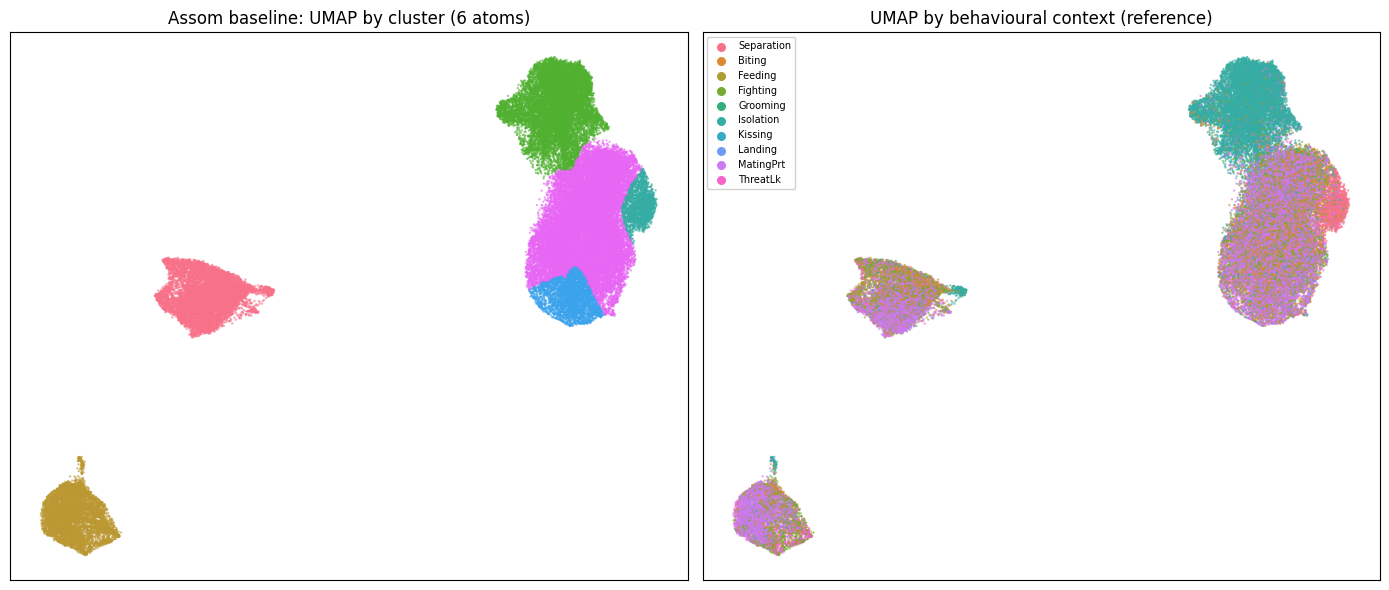

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_umap_scatter(embedding, labels_base, contexts, method, axes[0], axes[1])
plt.tight_layout(); plt.show()


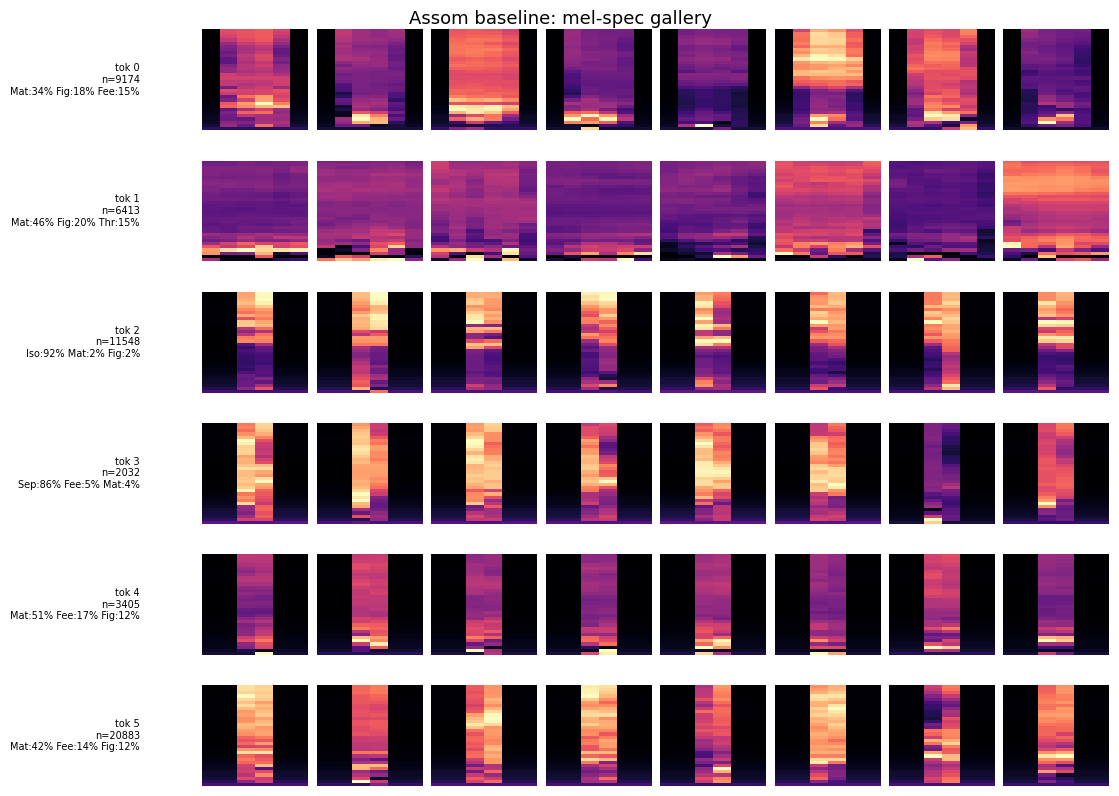

In [5]:
fig = plot_spectrogram_gallery(tf_specs, labels_base, contexts,
                                 f'{method}: mel-spec gallery')
plt.show()


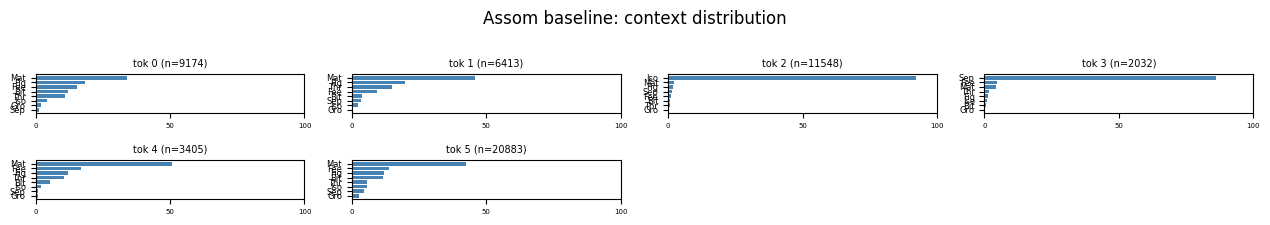

In [6]:
fig = plot_context_bars(labels_base, contexts, f'{method}: context distribution')
plt.show()


## 3. Mel DP-GMM on UMAP (k_max=40)

Non-parametric Bayesian clustering на глобальном UMAP. Гипотеза: более
тонкая гранулярность может выявить context-specific sub-types, которые
baseline (6 кластеров) схлопывает в catch-all.


In [7]:
# Fit DP-GMM (cached on disk if possible)
_dp_cache = CHECKPOINT_DIR / 'dp_mel_umap_k40.npy'
if _dp_cache.exists():
    dp_mel = np.load(_dp_cache)
    print(f'Loaded cached DP-GMM labels: {len(set(dp_mel))} clusters')
else:
    print('Fitting DP-GMM UMAP k=40 (~1 min)...')
    bgm = BayesianGaussianMixture(n_components=40,
                                    weight_concentration_prior_type='dirichlet_process',
                                    weight_concentration_prior=0.1,
                                    covariance_type='full', max_iter=100, random_state=0)
    dp_mel = bgm.fit_predict(embedding)
    cnt = Counter(int(x) for x in dp_mel)
    active = {k for k, v in cnt.items() if v >= 20}
    if len(active) < len(cnt):
        am = np.isin(dp_mel, list(active))
        if (~am).any():
            knn = NearestNeighbors(n_neighbors=1).fit(embedding[am])
            _, idx = knn.kneighbors(embedding[~am])
            dp_mel[~am] = dp_mel[am][idx.ravel()]
    np.save(_dp_cache, dp_mel)

# Compact labels
uniq = {v: i for i, v in enumerate(sorted(set(dp_mel)))}
dp_mel_compact = np.array([uniq[v] for v in dp_mel])

m = summary_metrics(dp_mel_compact, mel_flat, embedding, contexts, 'Mel DP-GMM UMAP k=40')
print(pd.DataFrame([m]).to_string(index=False))


Loaded cached DP-GMM labels: 21 clusters


              method  vocab  silh_native  silh_umap  ctx_H  ctx_purity
Mel DP-GMM UMAP k=40     21        0.046      0.277   1.99        0.42


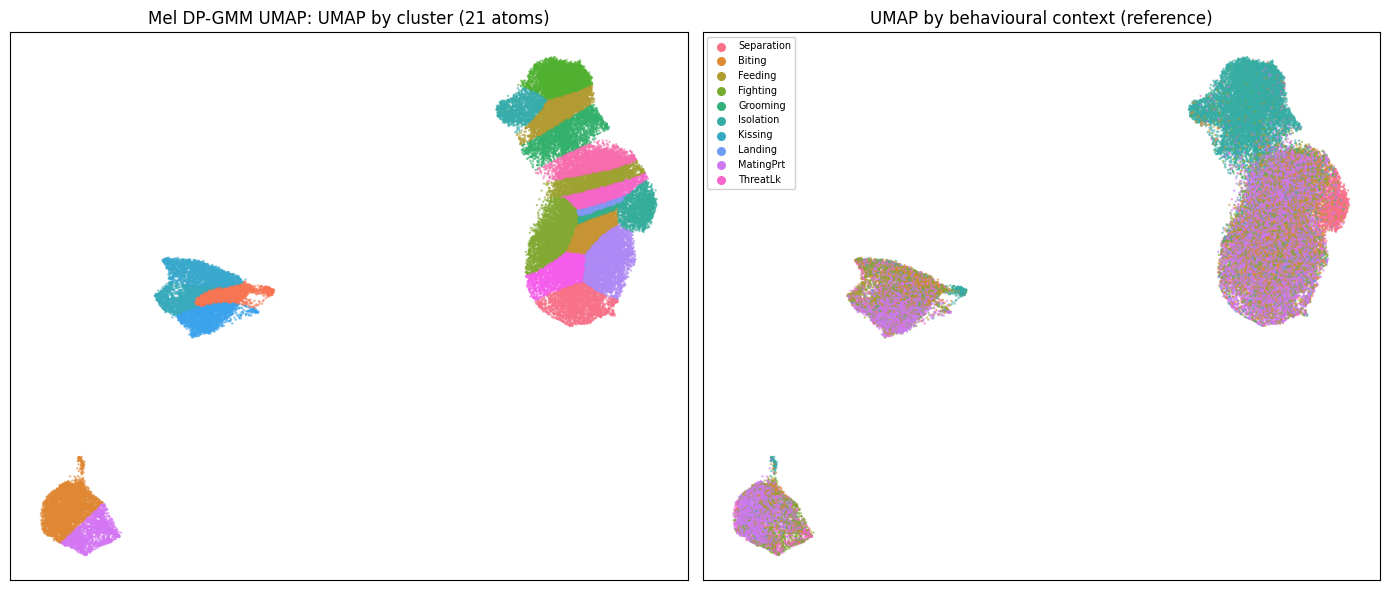

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_umap_scatter(embedding, dp_mel_compact, contexts, 'Mel DP-GMM UMAP', axes[0], axes[1])
plt.tight_layout(); plt.show()


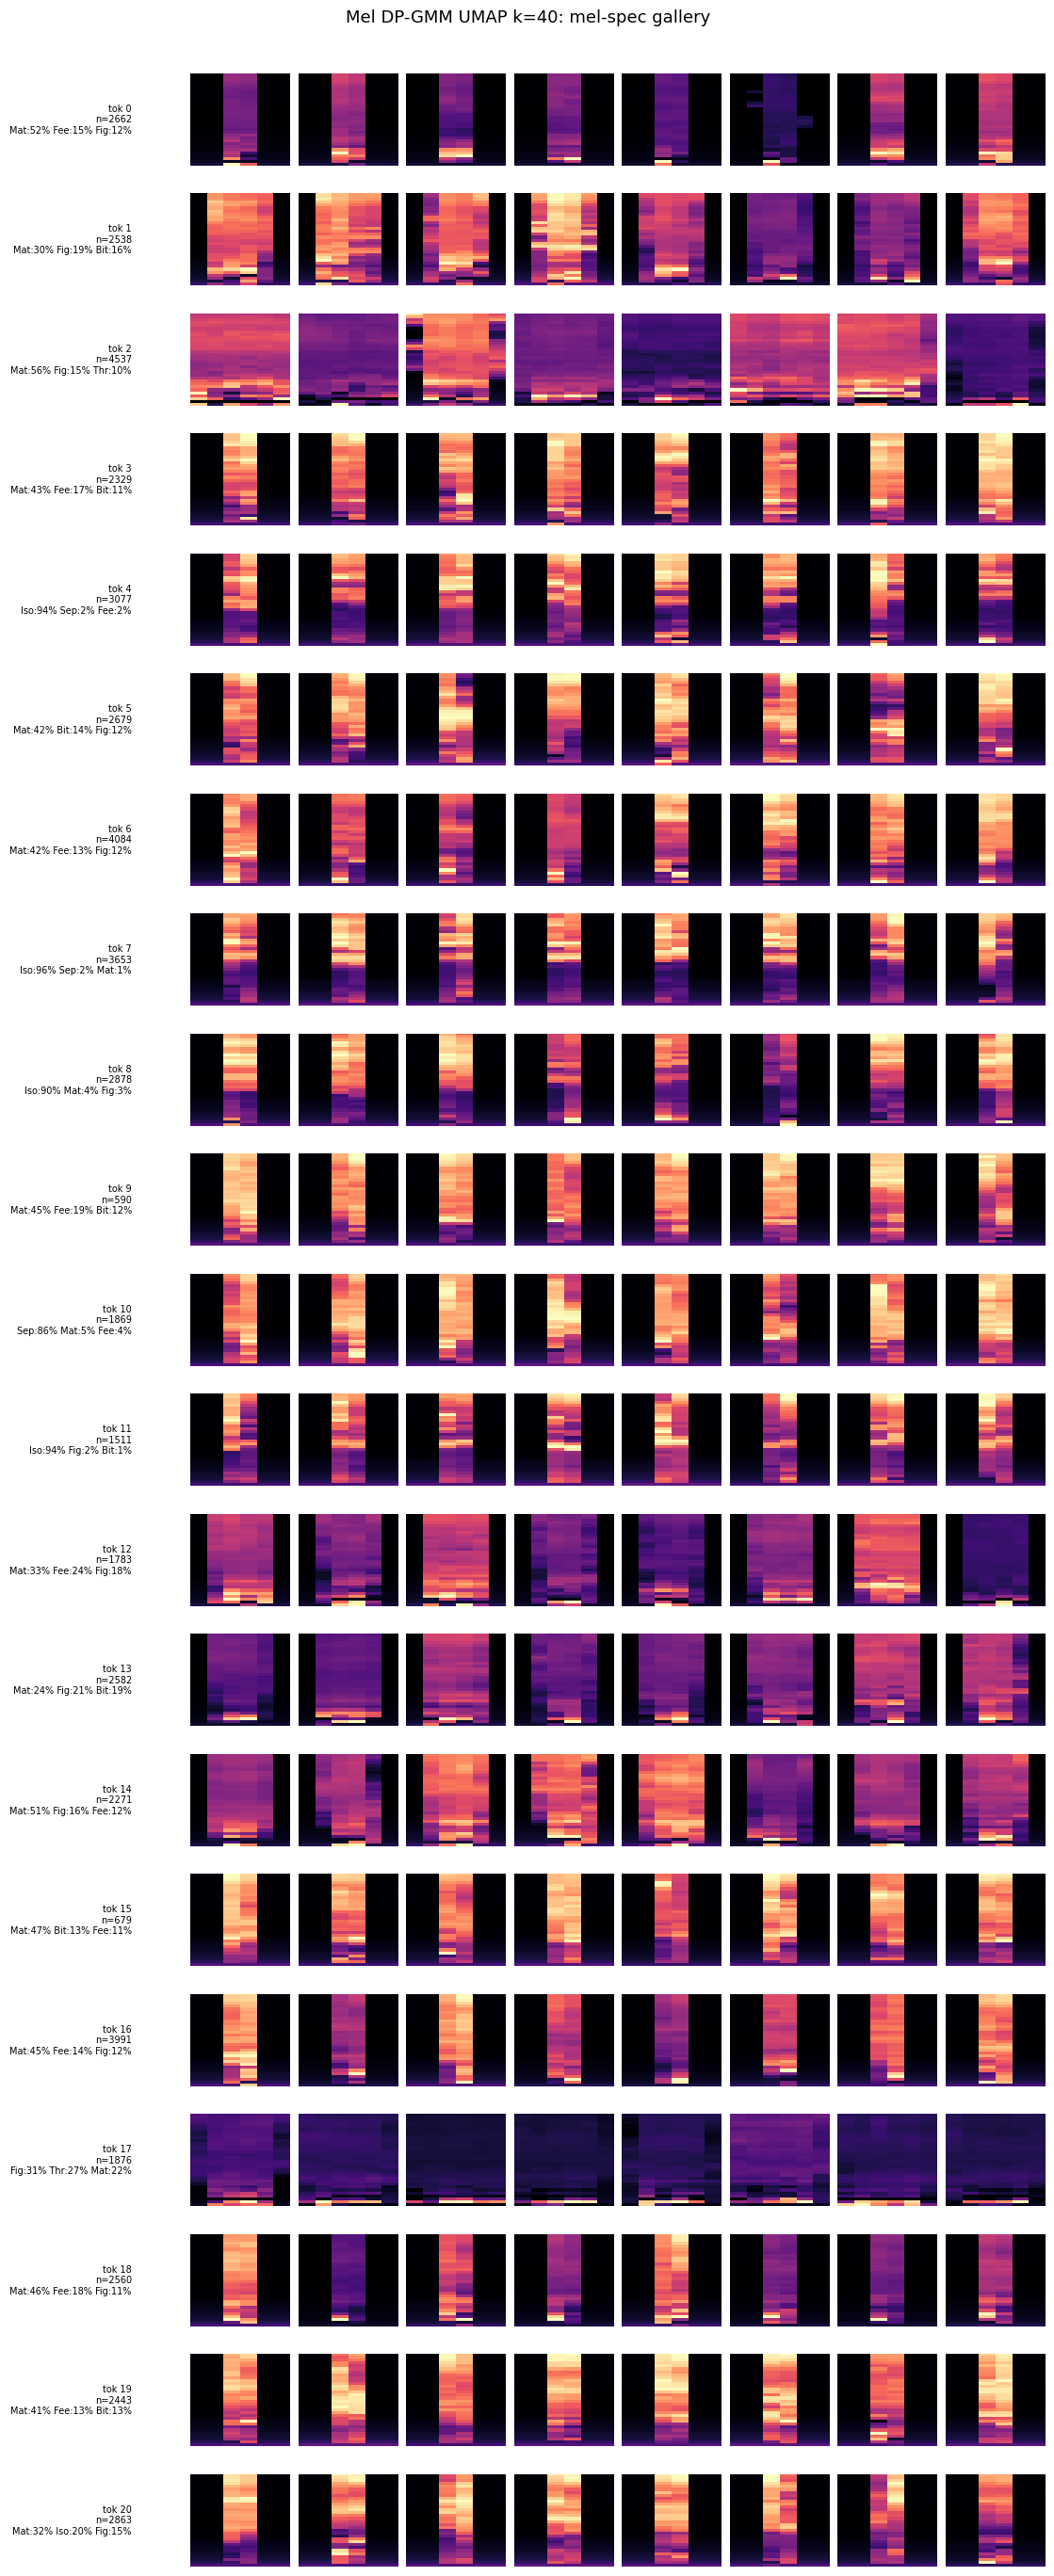

In [9]:
fig = plot_spectrogram_gallery(tf_specs, dp_mel_compact, contexts,
                                 'Mel DP-GMM UMAP k=40: mel-spec gallery')
plt.show()


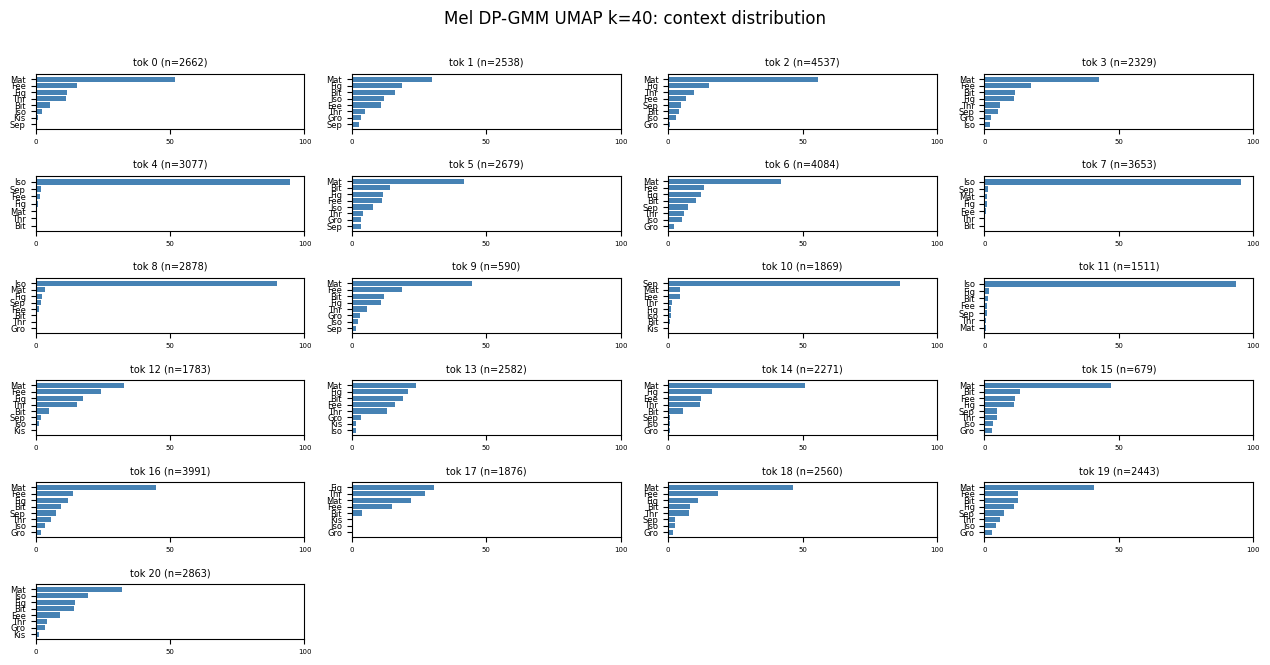

In [10]:
fig = plot_context_bars(dp_mel_compact, contexts,
                         'Mel DP-GMM UMAP k=40: context distribution')
plt.show()


## 4. Mel DP-GMM on native Mel 192D (k_max=20)

Лучший acoustic silhouette (0.618), но catastrofic ctx_purity (0.052).
Интересно посмотреть, как это выглядит — ожидаем «acoustically clean»
кластеры, не соответствующие поведенческим контекстам.


In [11]:
_dp_mel_cache = CHECKPOINT_DIR / 'dp_mel_native_k20.npy'
if _dp_mel_cache.exists():
    dp_native = np.load(_dp_mel_cache)
    print(f'Loaded cached: {len(set(dp_native))} clusters')
else:
    print('Fitting DP-GMM on Mel-192D k=20 (~3 min)...')
    bgm = BayesianGaussianMixture(n_components=20,
                                    weight_concentration_prior_type='dirichlet_process',
                                    weight_concentration_prior=0.1,
                                    covariance_type='full', max_iter=100, random_state=0)
    dp_native = bgm.fit_predict(mel_flat)
    cnt = Counter(int(x) for x in dp_native)
    active = {k for k, v in cnt.items() if v >= 20}
    if len(active) < len(cnt):
        am = np.isin(dp_native, list(active))
        if (~am).any():
            knn = NearestNeighbors(n_neighbors=1).fit(mel_flat[am])
            _, idx = knn.kneighbors(mel_flat[~am])
            dp_native[~am] = dp_native[am][idx.ravel()]
    np.save(_dp_mel_cache, dp_native)

uniq = {v: i for i, v in enumerate(sorted(set(dp_native)))}
dp_native_compact = np.array([uniq[v] for v in dp_native])

m = summary_metrics(dp_native_compact, mel_flat, embedding, contexts, 'Mel DP-GMM native')
print(pd.DataFrame([m]).to_string(index=False))


Fitting DP-GMM on Mel-192D k=20 (~3 min)...


           method  vocab  silh_native  silh_umap  ctx_H  ctx_purity
Mel DP-GMM native     14        0.618      0.697   2.11       0.052


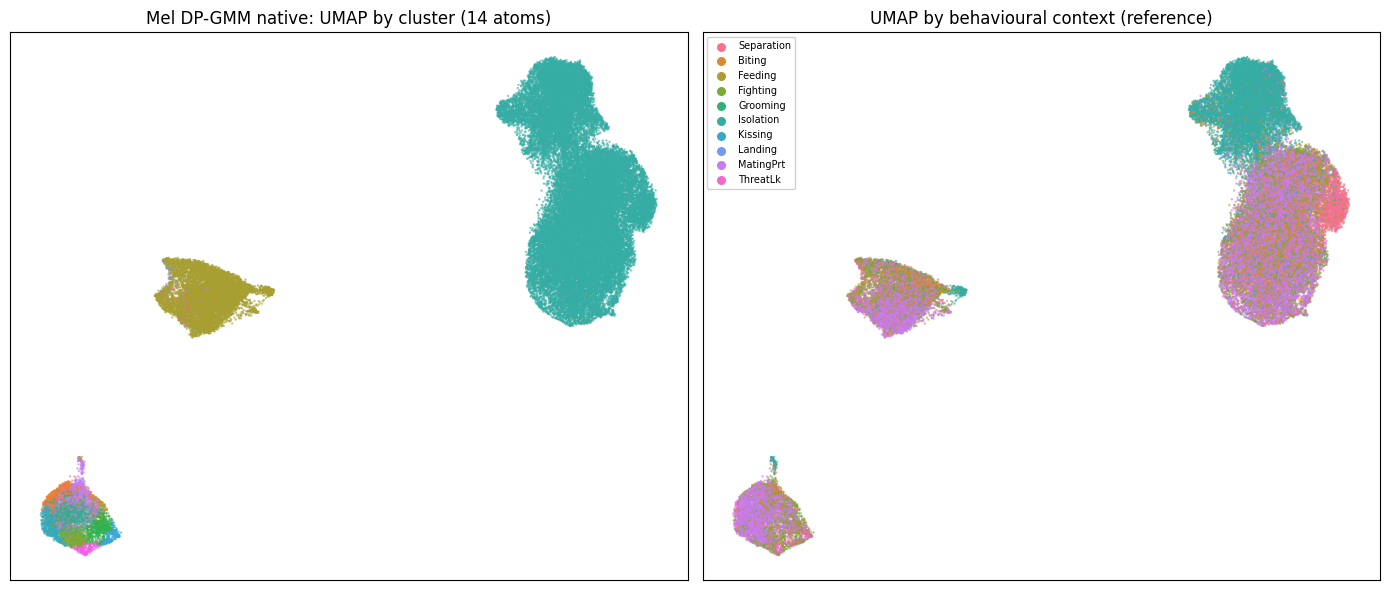

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_umap_scatter(embedding, dp_native_compact, contexts, 'Mel DP-GMM native', axes[0], axes[1])
plt.tight_layout(); plt.show()


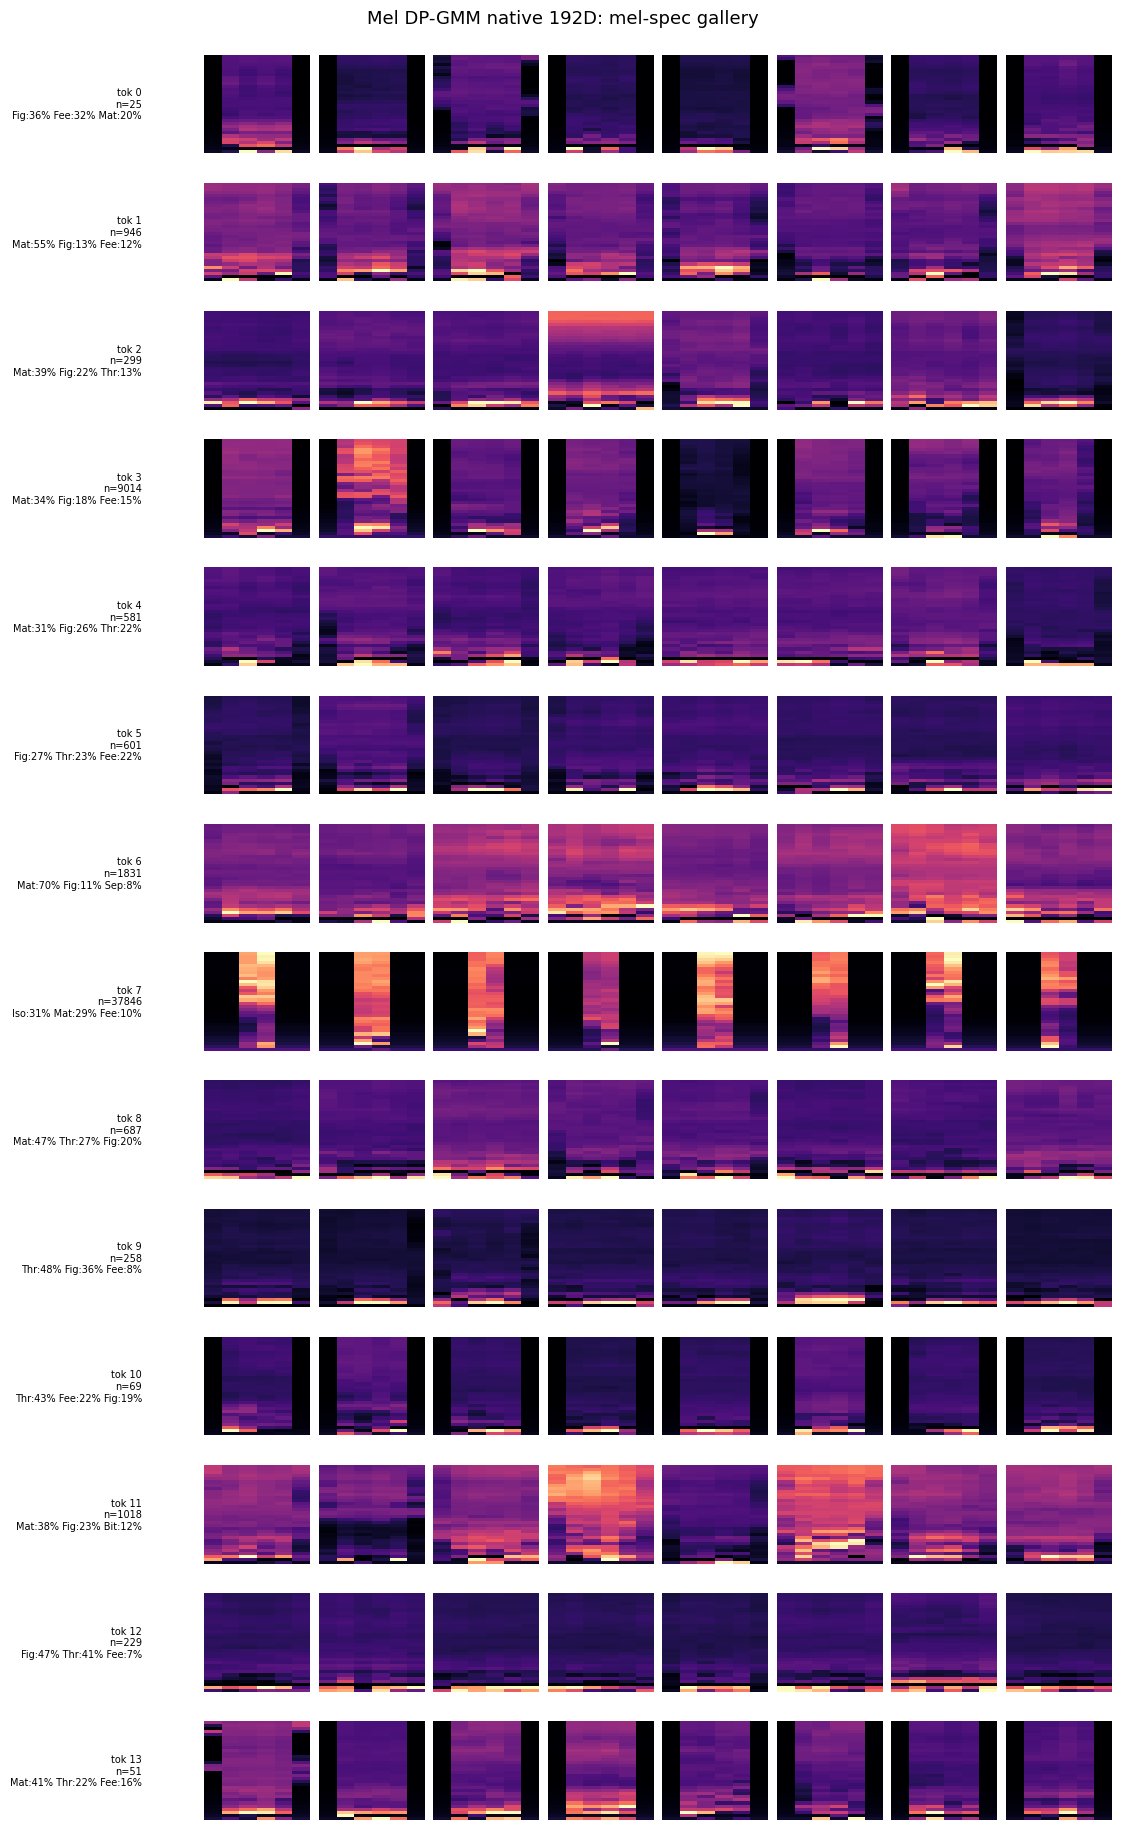

In [13]:
fig = plot_spectrogram_gallery(tf_specs, dp_native_compact, contexts,
                                 'Mel DP-GMM native 192D: mel-spec gallery')
plt.show()


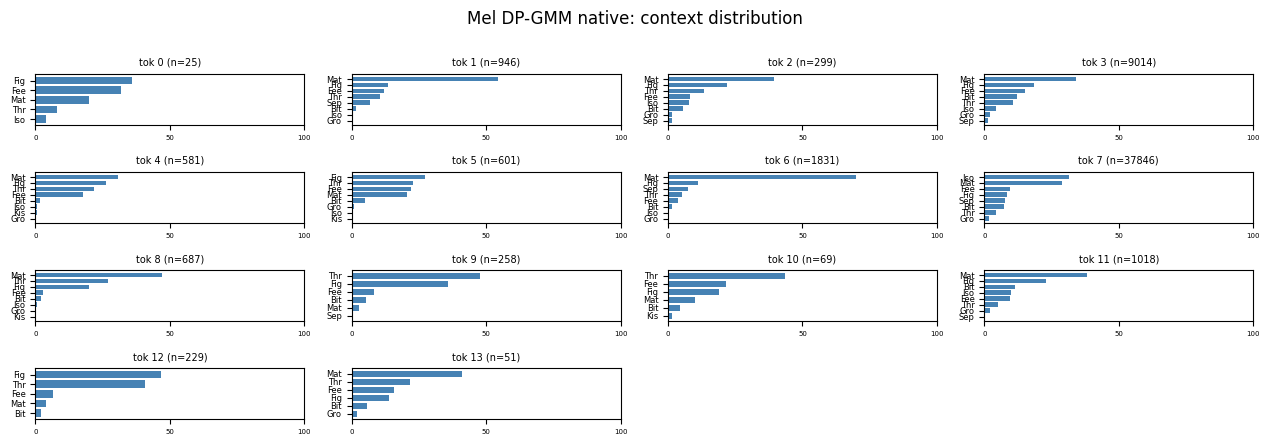

In [14]:
fig = plot_context_bars(dp_native_compact, contexts,
                         'Mel DP-GMM native: context distribution')
plt.show()


## 5. BEATs HDBSCAN+NCA on BEATs-UMAP

SSL-pretrained embeddings (NatureBEATs + pitch_shift) → UMAP → HDBSCAN.
BEATs данные из отдельного прогона (49604 сегмента). Показываем UMAP
scatter и context bars; mel-spec gallery не показываем (для BEATs
сегментов mel не сохранены).


In [15]:
if st_beats is not None:
    meta_b = st_beats['seg_meta']
    ctx_b = meta_b['context'].to_numpy()
    umap_b = st_beats['umap_beats']
    hdb_b = st_beats['hdb_nca']

    uniq = {v: i for i, v in enumerate(sorted(set(hdb_b)))}
    hdb_b_compact = np.array([uniq[v] for v in hdb_b])

    # For silhouette in native BEATs we'd need PCA of X_beats — reuse ‘fake' native
    m = {
        'method': 'BEATs HDBSCAN+NCA',
        'vocab': len(set(hdb_b_compact)) - (1 if -1 in hdb_b_compact else 0),
        'silh_umap': round(silhouette_score(umap_b[:8000], hdb_b_compact[:8000], random_state=0), 3),
        'ctx_H': round(ctx_metrics(hdb_b_compact, ctx_b)['mean_H'], 2),
        'ctx_purity': round(ctx_metrics(hdb_b_compact, ctx_b)['context_purity'], 3),
    }
    print(pd.DataFrame([m]).to_string(index=False))
else:
    print('BEATs state not available')


           method  vocab  silh_umap  ctx_H  ctx_purity
BEATs HDBSCAN+NCA     20      0.334   2.26       0.334


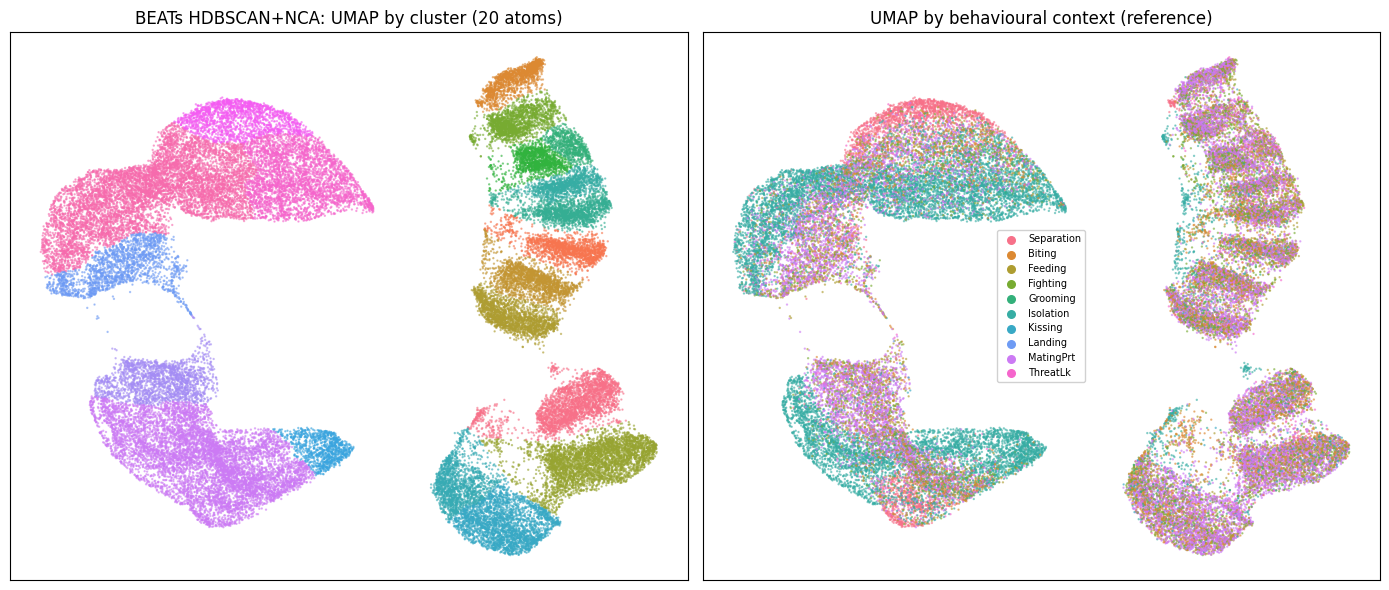

In [16]:
if st_beats is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_umap_scatter(umap_b, hdb_b_compact, ctx_b, 'BEATs HDBSCAN+NCA', axes[0], axes[1])
    plt.tight_layout(); plt.show()


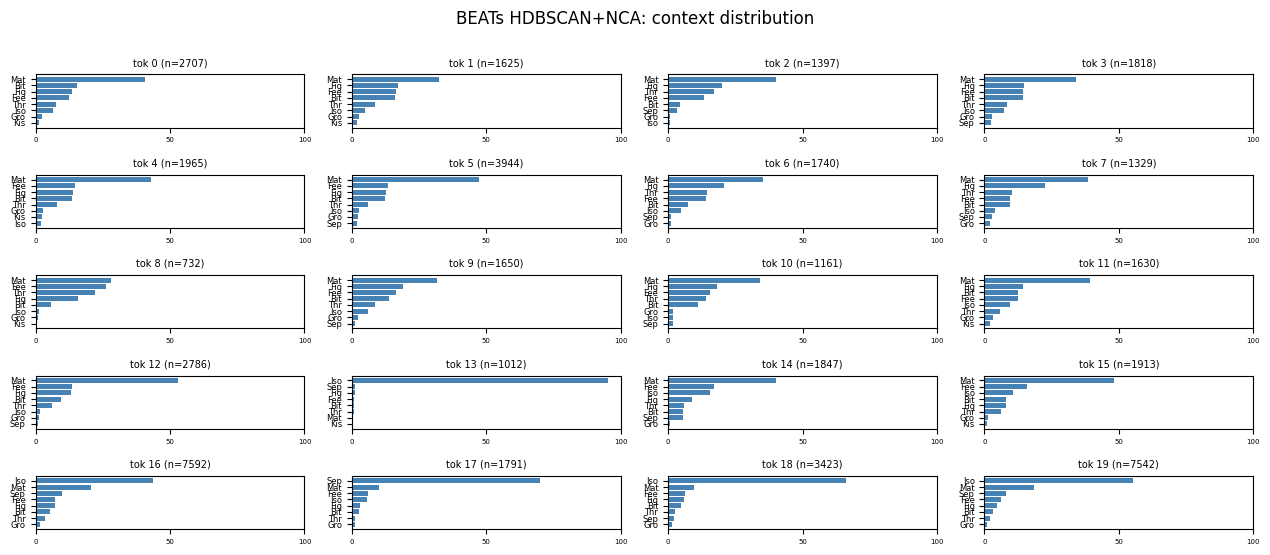

In [17]:
if st_beats is not None:
    fig = plot_context_bars(hdb_b_compact, ctx_b,
                             'BEATs HDBSCAN+NCA: context distribution')
    plt.show()


## 6. BEATs DP-GMM on BEATs-UMAP

Большая гранулярность (vocab ~34). Ожидаем множество «чистых»
context-specific токенов (Iso/Sep-specific) + богатое разбиение
adult-dialogue пространства.


In [18]:
if st_beats is not None:
    dp_b = st_beats['dp_umap']
    uniq = {v: i for i, v in enumerate(sorted(set(dp_b)))}
    dp_b_compact = np.array([uniq[v] for v in dp_b])

    m = {
        'method': 'BEATs DP-GMM UMAP',
        'vocab': len(set(dp_b_compact)) - (1 if -1 in dp_b_compact else 0),
        'silh_umap': round(silhouette_score(umap_b[:8000], dp_b_compact[:8000], random_state=0), 3),
        'ctx_H': round(ctx_metrics(dp_b_compact, ctx_b)['mean_H'], 2),
        'ctx_purity': round(ctx_metrics(dp_b_compact, ctx_b)['context_purity'], 3),
    }
    print(pd.DataFrame([m]).to_string(index=False))


           method  vocab  silh_umap  ctx_H  ctx_purity
BEATs DP-GMM UMAP     34      0.356   2.14       0.367


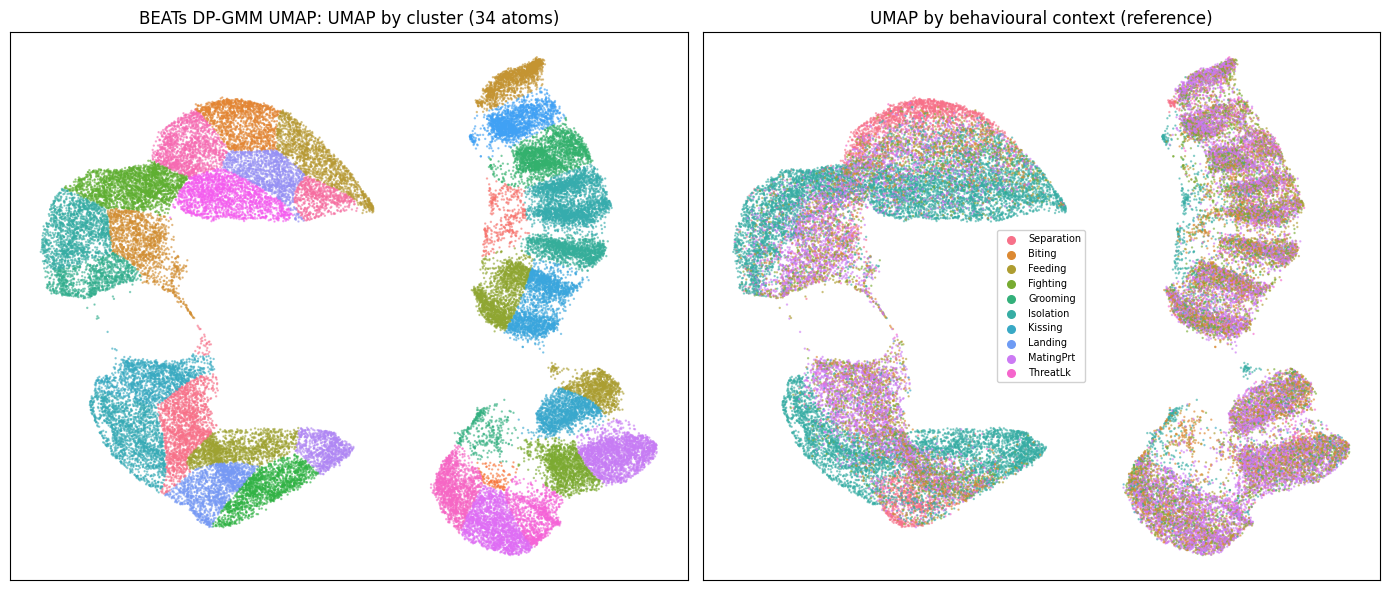

In [19]:
if st_beats is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_umap_scatter(umap_b, dp_b_compact, ctx_b, 'BEATs DP-GMM UMAP', axes[0], axes[1])
    plt.tight_layout(); plt.show()


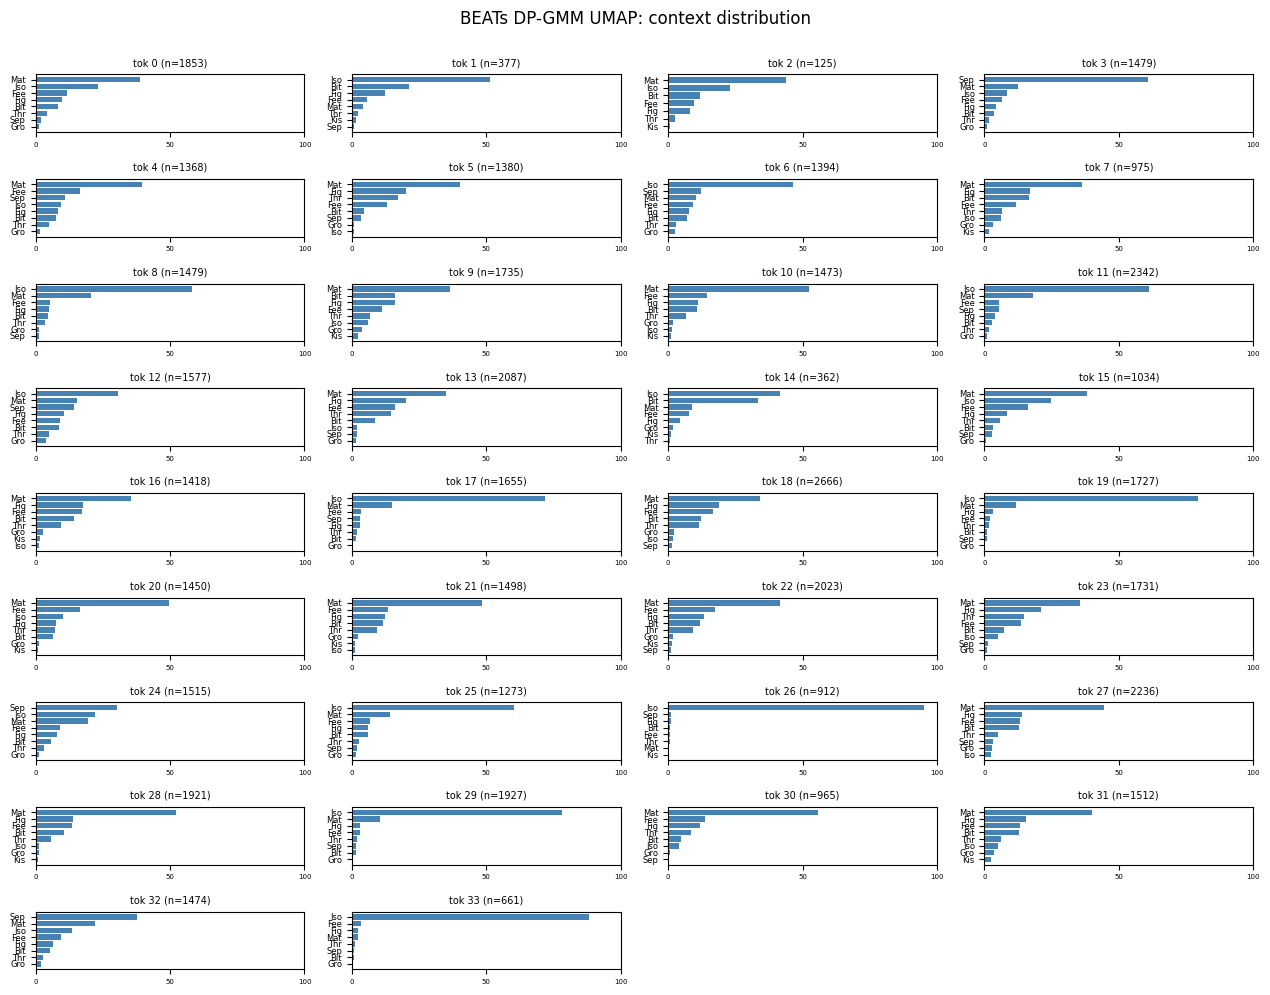

In [20]:
if st_beats is not None:
    fig = plot_context_bars(dp_b_compact, ctx_b,
                             'BEATs DP-GMM UMAP: context distribution')
    plt.show()


## 7. Cross-method summary

Сводная таблица всех методов из визуализаций выше + внешние результаты
(kmeans-split, A1 variants — см. `scripts/experiment_*.py`).


In [21]:
rows = []
rows.append(summary_metrics(labels_base, mel_flat, embedding, contexts, 'Assom baseline (6)'))
rows.append(summary_metrics(dp_mel_compact, mel_flat, embedding, contexts, f'Mel DP-GMM UMAP (~{len(set(dp_mel_compact))})'))
rows.append(summary_metrics(dp_native_compact, mel_flat, embedding, contexts, f'Mel DP-GMM native (~{len(set(dp_native_compact))})'))

if st_beats is not None:
    rows.append({
        'method': f'BEATs HDBSCAN+NCA ({len(set(hdb_b_compact))})',
        'vocab': len(set(hdb_b_compact)),
        'silh_native': round(silhouette_score(umap_b[:8000], hdb_b_compact[:8000], random_state=0), 3),
        'silh_umap': round(silhouette_score(umap_b[:8000], hdb_b_compact[:8000], random_state=0), 3),
        'ctx_H': round(ctx_metrics(hdb_b_compact, ctx_b)['mean_H'], 2),
        'ctx_purity': round(ctx_metrics(hdb_b_compact, ctx_b)['context_purity'], 3),
    })
    rows.append({
        'method': f'BEATs DP-GMM UMAP ({len(set(dp_b_compact))})',
        'vocab': len(set(dp_b_compact)),
        'silh_native': round(silhouette_score(umap_b[:8000], dp_b_compact[:8000], random_state=0), 3),
        'silh_umap': round(silhouette_score(umap_b[:8000], dp_b_compact[:8000], random_state=0), 3),
        'ctx_H': round(ctx_metrics(dp_b_compact, ctx_b)['mean_H'], 2),
        'ctx_purity': round(ctx_metrics(dp_b_compact, ctx_b)['context_purity'], 3),
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# Save
Path('docs/thesis/figures').mkdir(parents=True, exist_ok=True)
df_summary.to_csv('docs/thesis/figures/method_comparison.csv', index=False)


                 method  vocab  silh_native  silh_umap  ctx_H  ctx_purity
     Assom baseline (6)      6        0.196      0.467   1.84       0.318
  Mel DP-GMM UMAP (~21)     21        0.046      0.277   1.99       0.420
Mel DP-GMM native (~14)     14        0.618      0.697   2.11       0.052
 BEATs HDBSCAN+NCA (20)     20        0.334      0.334   2.26       0.334
 BEATs DP-GMM UMAP (34)     34        0.356      0.356   2.14       0.367


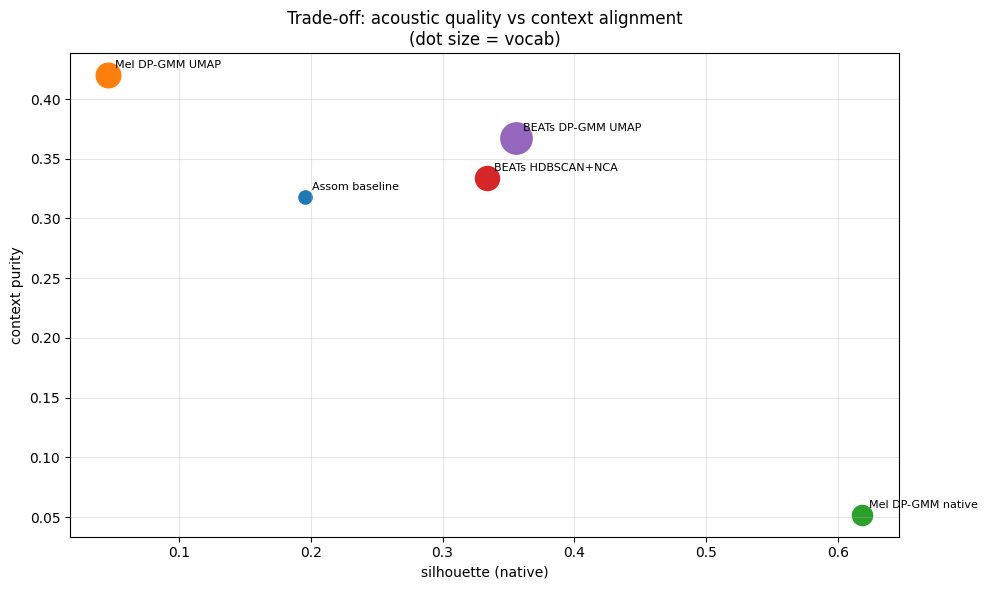

In [22]:
# Bar plot — ctx_purity vs silhouette trade-off
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in df_summary.iterrows():
    ax.scatter(r['silh_native'], r['ctx_purity'], s=max(r['vocab']*15, 30))
    ax.annotate(r['method'].split('(')[0].strip(), (r['silh_native'], r['ctx_purity']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('silhouette (native)')
ax.set_ylabel('context purity')
ax.set_title('Trade-off: acoustic quality vs context alignment\n(dot size = vocab)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
